# Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

We built models that predicts DIC (in µmol/kg) for seawater samples collected off the California coast. The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program and has been collected since 1949.

Through machine learning practices we learn the relationship between sea water temperature, total alkalinity, salinity, and depth. 

In [1]:
# load libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix)

In [2]:
# load in data
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [3]:
# view data
train.head()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


### Preliminary data exploration 

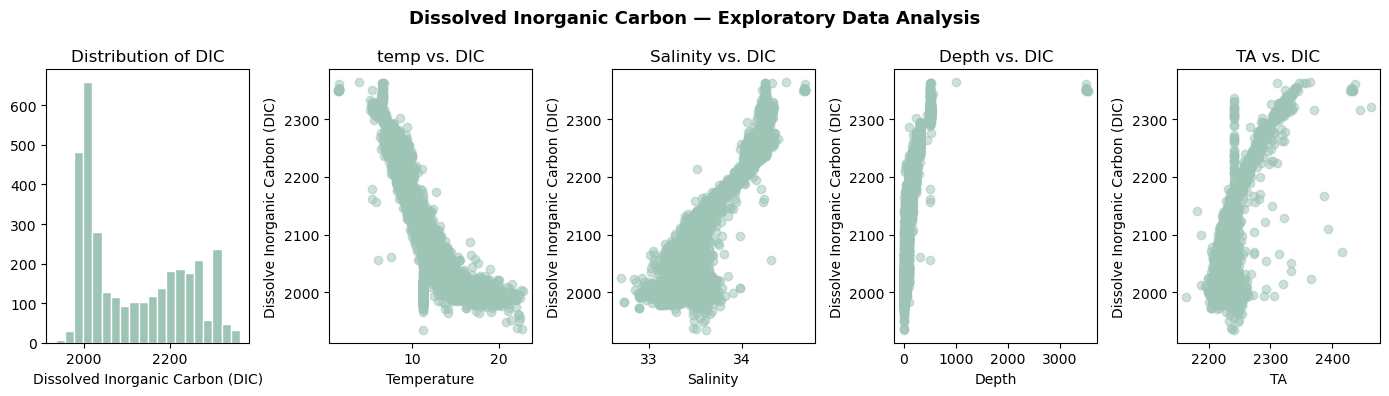

In [4]:
# visualize data
fig, axes = plt.subplots(1, 5, figsize=(14, 4))

# --- Plot 1: DIC distribution ---
axes[0].hist(train['DIC'], bins=20, color='#9DC4B5', edgecolor='white')
axes[0].set_xlabel('Dissolved Inorganic Carbon (DIC)')
axes[0].set_ylabel('')
axes[0].set_title('Distribution of DIC')

# --- Plot 2: DIC vs TEMP ---
axes[1].scatter(train['CTDTEMP_ITS90'], train['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[1].set_title("temp vs. DIC")

# --- Plot 3: DIC vs Slinity ---
axes[2].scatter(train['Salinity_PSS78'], train['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[2].set_xlabel("Salinity")
axes[2].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[2].set_title("Salinity vs. DIC")

# --- Plot 4: DIC vs Depth ---
axes[3].scatter(train['Depth'], train['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[3].set_xlabel("Depth")
axes[3].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[3].set_title("Depth vs. DIC")

# --- Plot 4: DIC vs TA ---
axes[4].scatter(train['TA'], train['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[4].set_xlabel("TA")
axes[4].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[4].set_title("TA vs. DIC")

plt.suptitle('Dissolved Inorganic Carbon — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Scale the predictor data

We need to scale the data but we never scale the response variable. So let's make two different objects to only scale the predictors.

In [5]:
# save separate predictor and response variables
X_train = train[['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']]
y_train = train['DIC']
X_test = test[['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']]

# scale the data
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Support Vector Regression (SVR)

### Radial Basis Function (RBF) Kernel

RBF measures similarity by distance and creates smooth regression curves in non-linear data. 

In [6]:
# make a parameter grid for the rbf model
param_grid = {'C' : [0.1, 1, 10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100],
              'gamma' : ['scale', 0.001, 0.01, 0.1, 1, 10]}

# define the rbf model to find the best parameters
grid_rbf = GridSearchCV(
    SVR(kernel = 'rbf'), 
    param_grid, 
    cv = 5, 
    scoring = 'r2', 
    n_jobs = -1)

# fit the rbf model to the data 
grid_rbf.fit(X_train_scaled, y_train)

# predict the test 
y_test_pred_rbf = grid_rbf.predict(X_test_scaled)

# access the rbf model's accuracy
rbf_best = grid_rbf.best_estimator_

print(f"Best parameters:  {grid_rbf.best_params_}")
print(f"CV R2:", {grid_rbf.best_score_})

Best parameters:  {'C': 1000, 'gamma': 1}
CV R2: {0.9508871367152046}


In [ ]:
submission = pd.DataFrame({"id": test["id"], "DIC": y_test_pred_rbf })
submission.to_csv("submission.csv", index=False)

### Polynomial Kernel

Polynomial kernels can fit data that follow polynomial relationships. Higher degrees can capture feature interactions.

In [ ]:
# make a parameter grid for the poly model
param_grid = {'C' : [0.1, 1, 10, 100],
              'gamma' : ['scale', 0.001, 0.01, 0.1, 1],
              'degree' : [2, 3, 4, 5],
              'coef0' : [0.0, 1.0]}

# define the poly model to find the best parameters
grid_poly = GridSearchCV(
    SVR(kernel = 'poly'), 
    param_grid, 
    cv = 5, 
    scoring = 'r2',
    n_jobs= -1)

# fit the poly model to the data
grid_poly.fit(X_train_scaled, y_train)

# predict the test 
y_test_pred_poly = grid_poly.predict(X_test_scaled)

# access the poly model's accuracy
poly_best = grid_poly.best_estimator_


print(f"Best parameters:  {grid_poly.best_params_}")
print(f"CV R2:", {grid_poly.best_score_})

Best parameters:  {'C': 100, 'coef0': 1.0, 'degree': 5, 'gamma': 0.01}
CV R2: {0.9143215134095979}


In [17]:
submission = pd.DataFrame({"id": test["id"], "DIC": y_test_pred_poly })
submission.to_csv("submission.csv", index=False)

### Visualize the poly predictions distributions

array([[<Axes: title={'center': '0'}>]], dtype=object)

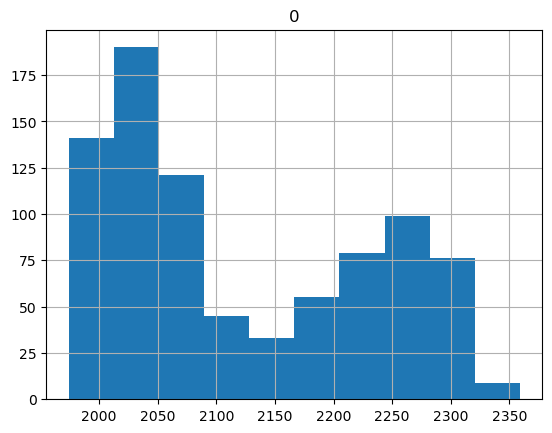

In [16]:
pd.DataFrame(y_test_pred_poly).hist()